In [1]:
#models
# r-train-models conda environment
library(plyr)
library(dplyr)
library(tidyverse)
library(caret)
library(recipes)
library(pROC)
library(devtools)
library(here)
library(rlucas)
library(reticulate)
library(cowplot)
library(FSelectorRcpp)

dir.create("../../outputs/Extended", recursive = TRUE, showWarnings = FALSE)




Attaching package: ‘dplyr’


The following objects are masked from ‘package:plyr’:

    arrange, count, desc, failwith, id, mutate, rename, summarise,
    summarize


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


── Attaching core tidyverse packages ───────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ readr     2.1.5
✔ ggplot2   3.5.2     ✔ stringr   1.5.1
✔ lubridate 1.9.4     ✔ tibble    3.2.1
✔ purrr     1.1.0     ✔ tidyr     1.3.1
── Conflicts ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::arrange()   masks plyr::arrange()
✖ purrr::compact()   masks plyr::compact()
✖ dplyr::count()     masks plyr::count()
✖ dplyr::desc()      masks plyr::desc()
✖ dplyr::failwith(

## Load data

In [2]:
lucas_df <- read.csv("../../data/lucas_df_with_pcs.csv")

lucas_df <- lucas_df %>%
  mutate(clinical_CEA = log2(clinical_CEA + 1))
lucas_df <- lucas_df %>% select(-olink_CEA)
merged_df <- lucas_df

## Proteomic OR Analysis

In [3]:
# =========================
# Dependencies
# =========================
library(tidyverse)
library(broom)
library(ggrepel)

# =========================
# Helper: compute ENT via PCA (95% variance by default)
# =========================
.compute_ENT <- function(df, feature_cols, var_explained = 0.95, min_n_per_feature = 10) {
  X <- df %>% select(all_of(feature_cols))
  keep <- names(X)[map_lgl(X, ~ sum(!is.na(.x)) >= min_n_per_feature && sd(.x, na.rm = TRUE) > 0)]
  if (length(keep) == 0) return(list(ENT = NA_integer_, used_cols = character(0)))

  X <- X %>% select(all_of(keep))
  Ximp <- X %>% mutate(across(everything(), ~ ifelse(is.na(.x), median(.x, na.rm = TRUE), .x)))
  pca <- prcomp(Ximp, center = TRUE, scale. = TRUE)
  ve  <- (pca$sdev^2) / sum(pca$sdev^2)
  ENT <- which(cumsum(ve) >= var_explained)[1]
  list(ENT = ENT, used_cols = keep)
}

# =========================
# Main: run_protein_lr
# =========================
run_protein_lr <- function(
  df,
  outcome_col = "type",                          # expects "cancer" vs not
  features_regex = "^olink_",                    # which features to scan
  include_clinical_CEA = TRUE,                   # include clinical_CEA (log2)
  covariates = c("clinical_age", "Sex", "clinical_smokingstatus"),
  correction = c("FDR", "ENT", "NONE"),          # multiple-testing method
  fdr_method = "BH",
  fdr_level = 0.05,                              # primary q-value threshold (stricter)
  fdr_level_secondary = NULL,                    # secondary threshold (more lenient, e.g., 0.10)
  ent_alpha = 0.05,                              # alpha used in ENT (alpha/ENT)
  ent_var_explained = 0.95,                      # % variance for ENT
  p_level = 0.05,                                # raw-p cutoff when NONE
  min_n = 20                                     # guardrail for complete cases
) {
  correction <- match.arg(correction)

  # ---- Prepare dataframe ----
  stopifnot(outcome_col %in% names(df))
  if (!all(covariates %in% names(df))) {
    missing_covs <- covariates[!covariates %in% names(df)]
    stop("These covariates were not found in df: ",
         paste(missing_covs, collapse = ", "))
  }

  dat <- df %>% mutate(type_bin = ifelse(.data[[outcome_col]] == "cancer", 1L, 0L))

  if ("Sex" %in% names(dat)) {
    dat <- dat %>% mutate(Sex = factor(Sex))
  }
  if ("clinical_smokingstatus" %in% names(dat)) {
    dat <- dat %>% mutate(
      clinical_smokingstatus = factor(clinical_smokingstatus,
                                      levels = c("never", "former", "current"),
                                      ordered = FALSE)
    )
  }

  # Identify feature columns
  feature_cols <- names(dat)[grepl(features_regex, names(dat))]
  if (include_clinical_CEA && "clinical_CEA" %in% names(dat)) {
    feature_cols <- c("clinical_CEA", feature_cols)
  }
  if (length(feature_cols) == 0) stop("No feature columns found.")

  # ---- Per-feature adjusted LR (OR per 1 SD) ----
  fit_one_adj <- function(d, feature, covs, min_n) {
    needed <- c("type_bin", covs, feature)
    d2 <- d %>% select(all_of(needed)) %>% drop_na()

    if (nrow(d2) < min_n || sd(d2[[feature]], na.rm = TRUE) == 0) {
      return(tibble(
        feature = feature, estimate = NA_real_, std.error = NA_real_,
        statistic = NA_real_, p.value = NA_real_,
        odds_ratio_sd = NA_real_, conf.low = NA_real_, conf.high = NA_real_, n = nrow(d2)
      ))
    }

    rhs  <- c("scale(x)", covs)
    form <- as.formula(paste("type_bin ~", paste(rhs, collapse = " + ")))
    mdat <- d2 %>% mutate(x = .data[[feature]])

    fit <- suppressWarnings(glm(form, data = mdat, family = binomial()))
    tt  <- tidy(fit, conf.int = TRUE)

    if (!("term" %in% names(tt)) || !any(tt$term == "scale(x)")) {
      return(tibble(
        feature = feature, estimate = NA_real_, std.error = NA_real_,
        statistic = NA_real_, p.value = NA_real_,
        odds_ratio_sd = NA_real_, conf.low = NA_real_, conf.high = NA_real_, n = nrow(d2)
      ))
    }

    row <- tt %>% filter(term == "scale(x)") %>% slice(1)

    tibble(
      feature = feature,
      estimate = row$estimate,
      std.error = row$std.error,
      statistic = if ("statistic" %in% names(row)) row$statistic else NA_real_,
      p.value = row$p.value,
      odds_ratio_sd = exp(row$estimate),
      conf.low = exp(row$conf.low),
      conf.high = exp(row$conf.high),
      n = nrow(d2)
    )
  }

  results <- map_dfr(feature_cols, ~ fit_one_adj(dat, .x, covariates, min_n)) %>%
    mutate(
      display_label = case_when(
        .data$feature == "clinical_CEA" ~ "CEA (CEACAM5)",
        startsWith(.data$feature, "olink_")   ~ sub("^olink_", "", .data$feature),
        TRUE ~ .data$feature
      )
    )

  # ---- Multiple testing choices (FDR / ENT / NONE) ----
  ENT_out <- NULL
  if (correction == "FDR") {
    results <- results %>%
      mutate(
        q.value = p.adjust(p.value, method = fdr_method)
      )
    
    # Handle dual thresholds for FDR
    if (!is.null(fdr_level_secondary)) {
      # Ensure primary is stricter (smaller) than secondary
      primary_thresh <- min(fdr_level, fdr_level_secondary)
      secondary_thresh <- max(fdr_level, fdr_level_secondary)
      
      results <- results %>%
        mutate(
          sig_primary = !is.na(q.value) & q.value < primary_thresh,
          sig_secondary = !is.na(q.value) & q.value >= primary_thresh & q.value < secondary_thresh,
          sig_flag = sig_primary | sig_secondary,  # for backward compatibility
          yval = -log10(pmax(q.value, .Machine$double.xmin)),
          cutoff_y_primary = -log10(primary_thresh),
          cutoff_y_secondary = -log10(secondary_thresh),
          cutoff_y = cutoff_y_primary  # for backward compatibility
        )
    } else {
      results <- results %>%
        mutate(
          sig_primary = !is.na(q.value) & q.value < fdr_level,
          sig_secondary = FALSE,
          sig_flag = sig_primary,
          yval = -log10(pmax(q.value, .Machine$double.xmin)),
          cutoff_y = -log10(fdr_level),
          cutoff_y_primary = cutoff_y,
          cutoff_y_secondary = NA_real_
        )
    }
    y_label <- expression(-log[10](FDR))

  } else if (correction == "ENT") {
    ENT_out <- .compute_ENT(dat, feature_cols, var_explained = ent_var_explained)
    ENT_val <- ENT_out$ENT

    if (is.na(ENT_val)) {
      warning("ENT could not be computed (no valid features); falling back to NONE with raw p-values.")
      results <- results %>%
        mutate(
          sig_primary = !is.na(p.value) & p.value < p_level,
          sig_secondary = FALSE,
          sig_flag = sig_primary,
          yval = -log10(pmax(p.value, .Machine$double.xmin)),
          cutoff_y = -log10(p_level),
          cutoff_y_primary = cutoff_y,
          cutoff_y_secondary = NA_real_
        )
      y_label <- expression(-log[10](p))
      correction <- "NONE"

    } else {
      ent_threshold <- ent_alpha / ENT_val
      results <- results %>%
        mutate(
          ENT = ENT_val,
          ENT_threshold = ent_threshold,
          sig_primary = !is.na(p.value) & p.value < ent_threshold,
          sig_secondary = FALSE,
          sig_flag = sig_primary,
          yval = -log10(pmax(p.value, .Machine$double.xmin)),
          cutoff_y = -log10(ent_threshold),
          cutoff_y_primary = cutoff_y,
          cutoff_y_secondary = NA_real_
        )
      y_label <- expression(-log[10](p))
      ENT_out <- c(ENT = ENT_val, threshold = ent_threshold)
    }

  } else { # NONE
    results <- results %>%
      mutate(
        sig_primary = !is.na(p.value) & p.value < p_level,
        sig_secondary = FALSE,
        sig_flag = sig_primary,
        yval = -log10(pmax(p.value, .Machine$double.xmin)),
        cutoff_y = -log10(p_level),
        cutoff_y_primary = cutoff_y,
        cutoff_y_secondary = NA_real_
      )
    y_label <- expression(-log[10](p))
  }

  # ---- Build plotting data from results ----
  volcano_data <- results %>%
    mutate(
      direction = case_when(
        is.na(odds_ratio_sd) ~ NA_character_,
        odds_ratio_sd > 1 ~ "OR>1",
        TRUE ~ "OR<1"
      ),
      # Create group with three significance levels
      sig_level = case_when(
        sig_primary ~ "primary",
        sig_secondary ~ "secondary",
        TRUE ~ "ns"
      ),
      grp = paste0(direction, " ", sig_level)
    )

  # Colors for direction × significance (three levels now)
  volcano_pal <- c(
    # Primary (most significant) - dark colors
    "OR>1 primary" = "#CD5C5C",
    "OR<1 primary" = "#08519C",
    # Secondary (between thresholds) - dark colors (same as primary)
    "OR>1 secondary" = "#CD5C5C",
    "OR<1 secondary" = "#08519C",
    # Not significant - light colors
    "OR>1 ns" = "#FFA07A",
    "OR<1 ns" = "#9ECAE1"
  )

  # Axis breaks for gridlines: every 1 on log2(OR), every 2 on −log10
  x_vals  <- log2(volcano_data$odds_ratio_sd)
  x_min   <- floor(min(x_vals[is.finite(x_vals)], na.rm = TRUE))
  x_max   <- ceiling(max(x_vals[is.finite(x_vals)], na.rm = TRUE))
  x_breaks <- seq(x_min, x_max, by = 1)

  y_max   <- ceiling(max(volcano_data$yval, na.rm = TRUE))
  y_breaks <- seq(0, max(2, y_max), by = 2)

  # ---- Publication-style volcano plot ----
  volcano_plot <- ggplot(volcano_data, aes(x = log2(odds_ratio_sd), y = yval)) +
    # threshold & reference lines - primary threshold
    geom_hline(aes(yintercept = cutoff_y_primary), linetype = "dashed", color = "gray40", linewidth = 0.6)
  
  # Add secondary threshold line if it exists
  if (!is.null(fdr_level_secondary) && correction == "FDR") {
    volcano_plot <- volcano_plot +
      geom_hline(aes(yintercept = cutoff_y_secondary), linetype = "dotted", color = "gray60", linewidth = 0.6)
  }
  
  volcano_plot <- volcano_plot +
    geom_vline(xintercept = 0, linetype = "dotted", color = "gray50", linewidth = 0.7) +
    # base points
    geom_point(aes(color = grp), size = 6, alpha = 0.8, na.rm = TRUE) +
    # black ring around primary significant points only
    geom_point(
      data = dplyr::filter(volcano_data, sig_primary),
      aes(x = log2(odds_ratio_sd), y = yval),
      shape = 21, fill = NA, color = "black", stroke = 1.5, size = 6.5, inherit.aes = FALSE
    ) +
    # labels for primary AND secondary significant proteins
    geom_text_repel(
      data = dplyr::filter(volcano_data, sig_primary | sig_secondary),
      aes(label = display_label),
      size = 7,
      box.padding = 1.0,
      point.padding = 1.2,
      max.overlaps = Inf,
      segment.color = "gray45",
      segment.size = 0.35
    ) +
    # color mapping (legend removed in theme)
    scale_color_manual(
      values = volcano_pal,
      breaks = c("OR>1 primary", "OR>1 secondary", "OR>1 ns",
                 "OR<1 primary", "OR<1 secondary", "OR<1 ns"),
      labels = c("OR>1, primary", "OR>1, secondary", "OR>1, ns",
                 "OR<1, primary", "OR<1, secondary", "OR<1, ns")
    ) +
    # gridline control
    scale_x_continuous(
      breaks = x_breaks, labels = x_breaks,
      expand = expansion(mult = c(0.02, 0.05))
    ) +
    scale_y_continuous(
      breaks = y_breaks, limits = c(0, NA),
      expand = expansion(mult = c(0.02, 0.07))
    ) +
    labs(title = NULL, x = expression("log"[2]*"(OR) per S.D."), y = y_label) +
    # publication look: border, no background grid (only explicit threshold lines remain), no legend
    theme_bw(base_size = 18) +
    theme(
      panel.grid.major = element_blank(),
      panel.grid.minor = element_blank(),
      panel.border     = element_rect(color = "black", fill = NA, linewidth = 1.2),
      legend.position  = "none",
      axis.text  = element_text(size = 18),
      axis.title = element_text(size = 25, face = "bold"),
      plot.background  = element_rect(fill = "white", color = NA),
      plot.margin      = margin(12, 22, 10, 10)
    )

  out <- list(results = results, plot = volcano_plot, correction = correction)
  if (!is.null(ENT_out)) out$ENT <- ENT_out
  out
}

In [4]:
# FDR (standard BH at 5%)
res_fdr <- run_protein_lr(
  df = lucas_df,
  outcome_col = "type",
  covariates = c("clinical_age", "clinical_sex", "clinical_smokingstatus"),
  correction = "FDR",
  fdr_level = 0.05,
  fdr_level_secondary = 0.10
)

# Create df2 from FDR results
df2 <- res_fdr$results %>%
  mutate(
    Protein = case_when(
      feature == "clinical_CEA" ~ "CEA (CEACAM5)",
      str_starts(feature, "olink_") ~ str_remove(feature, "olink_"),
      TRUE ~ feature
    ),
    log10_pvalue = -log10(p.value)
  ) %>%
  arrange(p.value)

# Extended Data Fig. 1a - Expanded Covariates

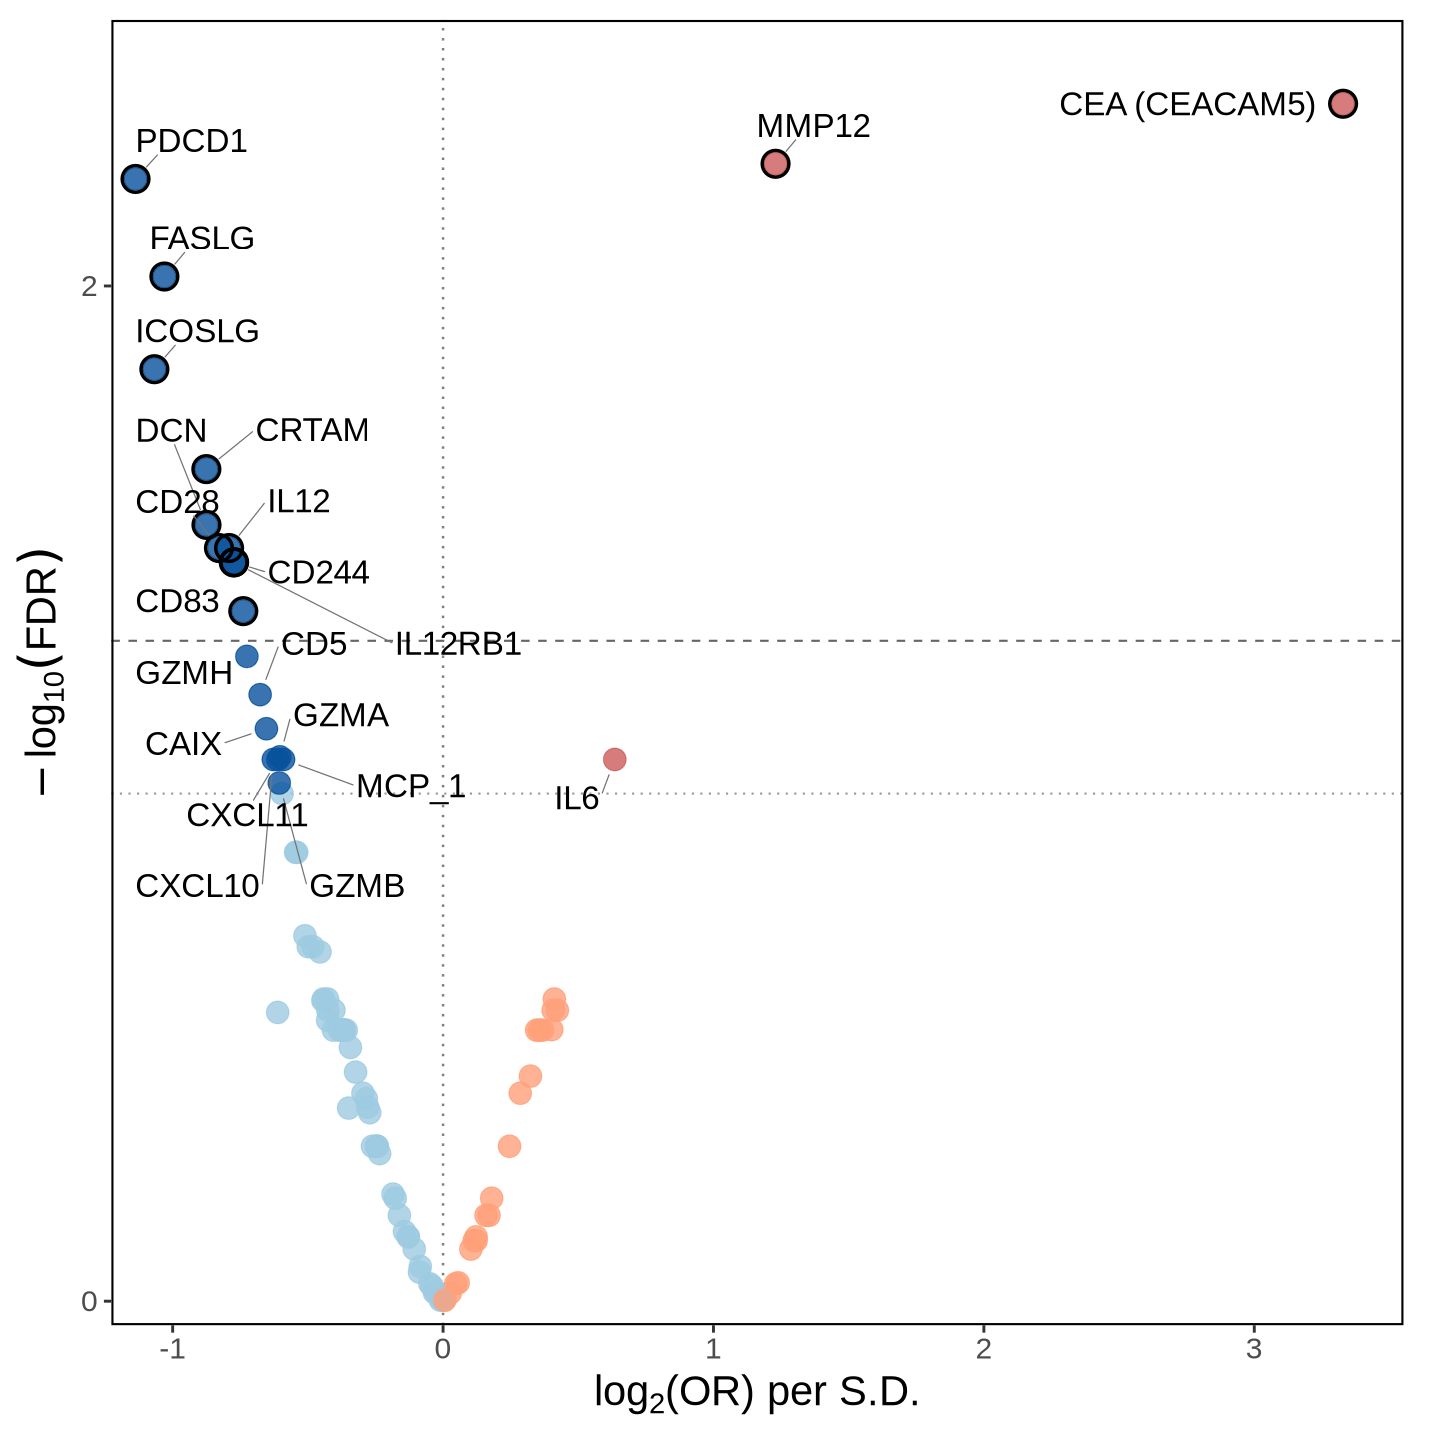

In [5]:
options(repr.plot.width = 12, repr.plot.height = 12)

# FDR (standard BH at 5%)
res_fdr_2 <- run_protein_lr(
  df = lucas_df,
  outcome_col = "type",
  covariates = c("clinical_age", "clinical_sex", "clinical_smokingstatus", "clinical_bmi", "clinical_COPD", "clinical_heart_condition", "clinical_pneumonia"),
  correction = "FDR",
  fdr_level = 0.05,
  fdr_level_secondary = 0.10
)
res_fdr_2$plot


ggsave(
  filename = "../../outputs/Extended/Ext-Data-Fig1a-Protein-Volcano-Plot-SD-FDR-Covariates.png",   # or .pdf, .tiff, etc.
  plot     = res_fdr_2$plot,
  width    = 12,      # inches
  height   = 12,      # inches
  dpi      = 600,     # publication quality
  bg       = "white", 
    create.dir = TRUE
)

# Extended Data Fig. 1b: HPA Proteomics

In [6]:
library(readr)
library(dplyr)

blood_pea <- read_tsv("../../data/blood_pea_disease_de.tsv")
lucas_data <- read_csv("../../data/Suppl-Proteomic-OR-Results.csv")

# Filter blood_pea to lung cancer vs all other diseases
filtered_blood_pea <- blood_pea %>%
  filter(Disease == "Lung cancer", Control == "All other diseases")

# Get lucas symbols (cleaned: uppercase, no hyphens/underscores/periods)
clean_symbol <- function(x) toupper(gsub("[\\-_\\.]", "", x))
lucas_symbols_clean <- clean_symbol(na.omit(unique(lucas_data$suggested_symbol)))

# Final dataset: cleaned matching
filtered_blood_pea_final <- filtered_blood_pea %>%
  filter(clean_symbol(Gene) %in% lucas_symbols_clean)

cat("Final filtered dataset:\n",
    "Rows:", nrow(filtered_blood_pea_final), "\n",
    "Unique proteins:", n_distinct(filtered_blood_pea_final$Gene), "\n",
    "Unique Controls:", unique(filtered_blood_pea_final$Control), "\n")

Rows: 205674 Columns: 7
── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (5): Gene, ENSG ID, Disease, Class, Control
dbl (2): logFC, p-value adjusted

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 93 Columns: 25
── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr  (8): feature, display_label, Protein, suggested_symbol, Gene, gene_biot...
dbl (14): estimate, std.error, statistic, p.value, odds_ratio_sd, conf.low, ...
lgl  (3): sig_primary, sig_secondary, sig_flag

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Final filtered dataset:
 Rows: 65 
 Unique proteins: 65 
 Unique Controls: All other diseases 


Rows: 205674 Columns: 7
── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (5): Gene, ENSG ID, Disease, Class, Control
dbl (2): logFC, p-value adjusted

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 93 Columns: 25
── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr  (8): feature, display_label, Protein, suggested_symbol, Gene, gene_biot...
dbl (14): estimate, std.error, statistic, p.value, odds_ratio_sd, conf.low, ...
lgl  (3): sig_primary, sig_secondary, sig_flag

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Final filtered dataset:
 Rows: 1162 
 Unique proteins: 1162 
 Unique Controls: All other diseases 


Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Warning message:
“ggrepel: 25 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


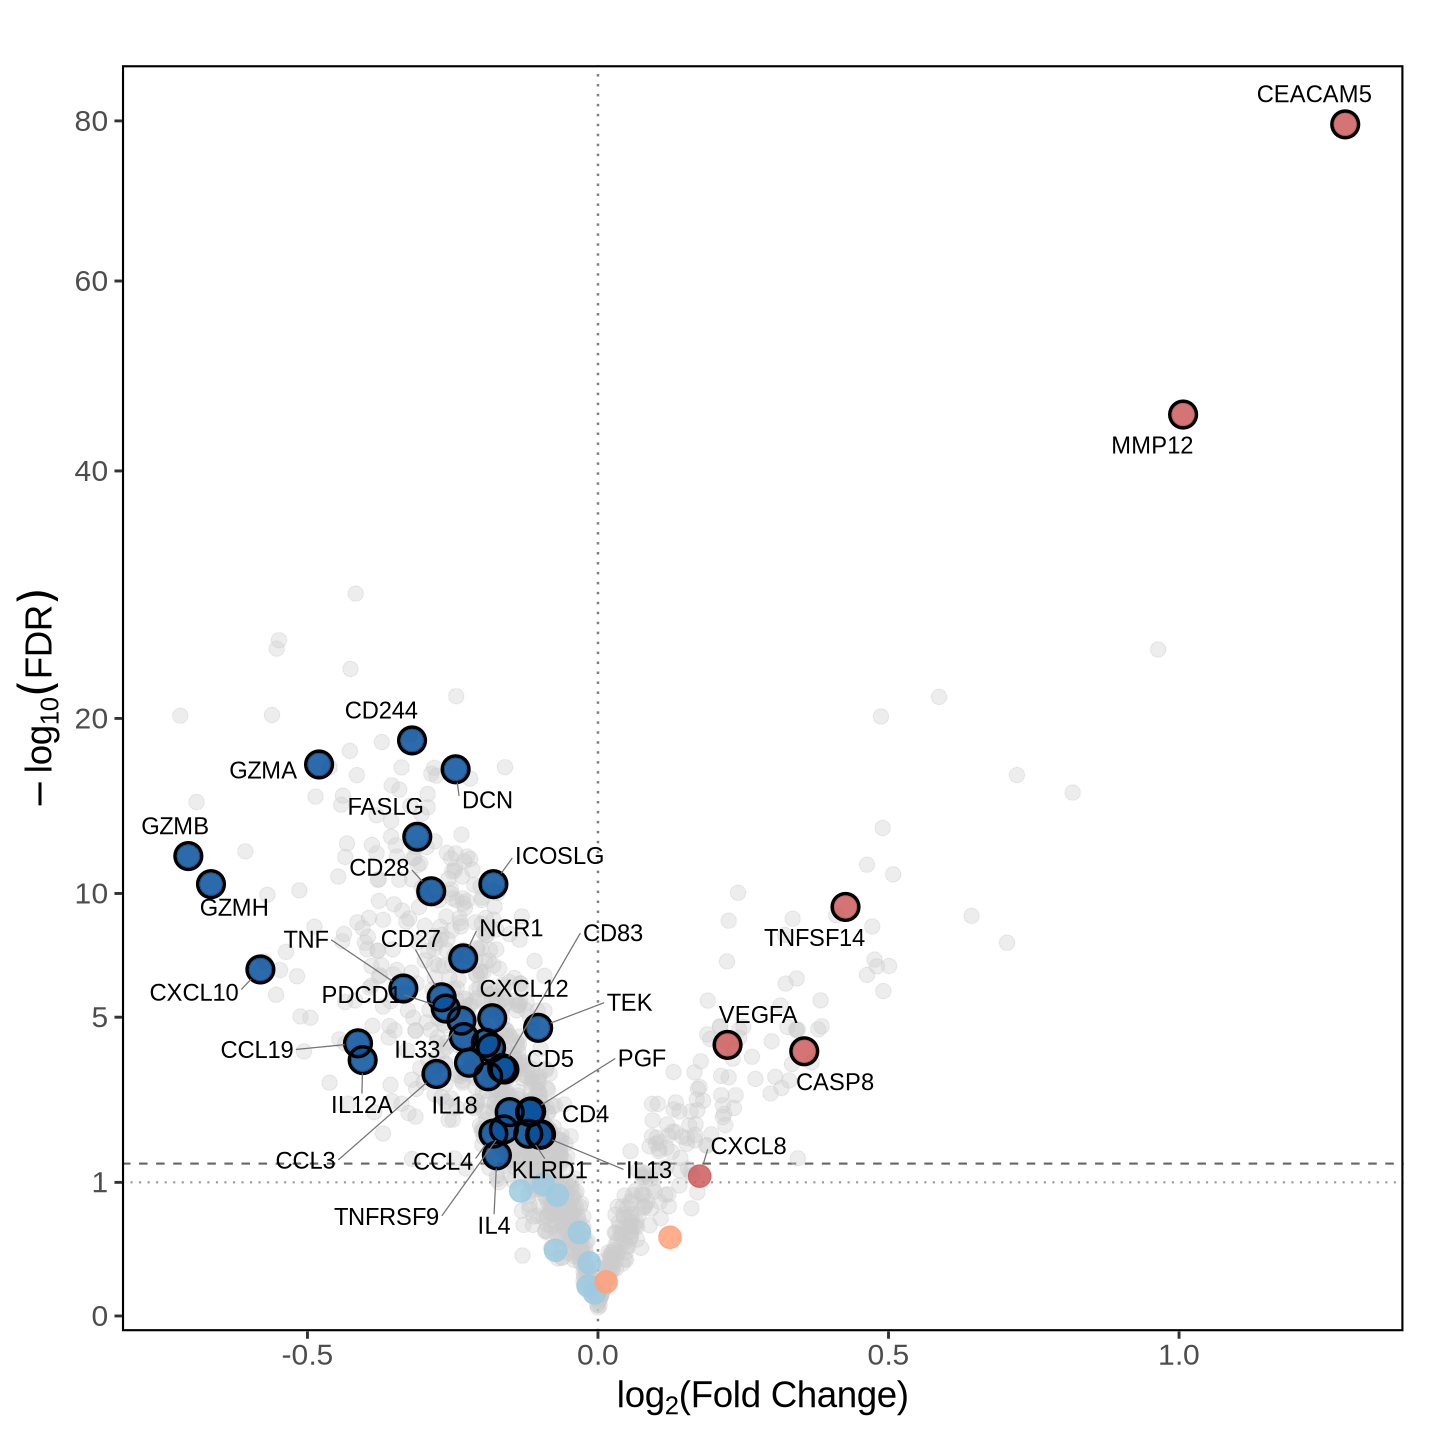

In [7]:
library(readr)
library(dplyr)
library(ggplot2)
library(ggrepel)

blood_pea <- read_tsv("../../data/blood_pea_disease_de.tsv")
lucas_data <- read_csv("../../data/Suppl-Proteomic-OR-Results.csv")

# Filter blood_pea to lung cancer vs Healthy
filtered_blood_pea <- blood_pea %>%
  filter(Disease == "Lung cancer", Control == "All other diseases")

# Get lucas symbols with direction (cleaned: uppercase, no hyphens/underscores/periods)
clean_symbol <- function(x) toupper(gsub("[\\-_\\.]", "", x))

lucas_direction <- lucas_data %>%
  filter(!is.na(suggested_symbol)) %>%
  mutate(
    clean_gene = clean_symbol(suggested_symbol),
    lucas_direction = case_when(
      estimate > 0 ~ "Up",
      estimate < 0 ~ "Down",
      TRUE         ~ NA_character_
    )
  ) %>%
  select(clean_gene, lucas_direction) %>%
  distinct(clean_gene, .keep_all = TRUE)

lucas_symbols_clean <- lucas_direction$clean_gene

# Final dataset: ALL proteins (no Lucas subsetting)
filtered_blood_pea_final <- filtered_blood_pea

cat("Final filtered dataset:\n",
    "Rows:", nrow(filtered_blood_pea_final), "\n",
    "Unique proteins:", n_distinct(filtered_blood_pea_final$Gene), "\n",
    "Unique Controls:", unique(filtered_blood_pea_final$Control), "\n")

# =========================
# Create volcano plot from filtered_blood_pea_final
# =========================

volcano_data_pea <- filtered_blood_pea_final %>%
  filter(Control == "All other diseases") %>%
  mutate(
    display_label = Gene,
    logFC  = logFC,
    p_adj  = `p-value adjusted`,

    yval = -log10(pmax(p_adj, .Machine$double.xmin)),

    fdr_level_primary   = 0.05,
    fdr_level_secondary = 0.10,

    sig_primary   = !is.na(p_adj) & p_adj < fdr_level_primary,
    sig_secondary = !is.na(p_adj) & p_adj >= fdr_level_primary & p_adj < fdr_level_secondary,

    direction = case_when(
      is.na(logFC) ~ NA_character_,
      logFC > 0    ~ "Up",
      TRUE         ~ "Down"
    ),

    sig_level = case_when(
      sig_primary   ~ "primary",
      sig_secondary ~ "secondary",
      TRUE          ~ "ns"
    ),

    grp = paste0(direction, " ", sig_level),

    cutoff_y_primary   = -log10(fdr_level_primary),
    cutoff_y_secondary = -log10(fdr_level_secondary),

    clean_gene = clean_symbol(Gene)
  ) %>%
  # Join Lucas direction info
  left_join(lucas_direction, by = "clean_gene") %>%
  mutate(
    # In Lucas set?
    in_lucas = clean_gene %in% lucas_symbols_clean,

    # Direction matches between HPA and Lucas?
    direction_match = in_lucas & !is.na(lucas_direction) & direction == lucas_direction,

    # Final color group: colored only if in Lucas AND direction matches AND significant
    # Everything else gets greyed out
    grp_plot = case_when(
      in_lucas & direction_match & sig_primary   ~ paste0(direction, " primary"),
      in_lucas & direction_match & sig_secondary ~ paste0(direction, " secondary"),
      in_lucas & direction_match                 ~ paste0(direction, " ns"),
      TRUE                                       ~ "grey"
    ),

    # Label only Lucas proteins with matching direction that are significant
    show_label = in_lucas & direction_match & (sig_primary | sig_secondary)
  )

# Color palette — grey for everything not matching
volcano_pal <- c(
  "Up primary"     = "#CD5C5C",
  "Down primary"   = "#08519C",
  "Up secondary"   = "#CD5C5C",
  "Down secondary" = "#08519C",
  "Up ns"          = "#FFA07A",
  "Down ns"        = "#9ECAE1",
  "grey"           = "grey80"
)

# Point size/alpha: subdue non-Lucas proteins visually
volcano_data_pea <- volcano_data_pea %>%
  mutate(
    pt_alpha = if_else(grp_plot == "grey", 0.35, 0.85),
    pt_size  = if_else(grp_plot == "grey", 4.0,  6.0)
  )

# Axis breaks
x_vals   <- volcano_data_pea$logFC
x_min    <- floor(min(x_vals[is.finite(x_vals)], na.rm = TRUE))
x_max    <- ceiling(max(x_vals[is.finite(x_vals)], na.rm = TRUE))
x_breaks <- seq(x_min, x_max, by = 0.5)

y_max    <- ceiling(max(volcano_data_pea$yval, na.rm = TRUE))
y_breaks <- seq(0, max(2, y_max), by = 10)

# Build the plot — plot grey points first so colored points sit on top
volcano_plot_pea <- ggplot() +

  # Threshold lines
  geom_hline(yintercept = -log10(0.05), linetype = "dashed", color = "gray40", linewidth = 0.6) +
  geom_hline(yintercept = -log10(0.10), linetype = "dotted", color = "gray60", linewidth = 0.6) +
  geom_vline(xintercept = 0,            linetype = "dotted", color = "gray50", linewidth = 0.7) +

  # Grey (non-Lucas or direction-mismatched) points — plotted first, underneath
  geom_point(
    data = dplyr::filter(volcano_data_pea, grp_plot == "grey"),
    aes(x = logFC, y = yval),
    color = "grey80", size = 4.0, alpha = 0.35, na.rm = TRUE
  ) +

  # Colored (Lucas-matching) points — plotted on top
  geom_point(
    data = dplyr::filter(volcano_data_pea, grp_plot != "grey"),
    aes(x = logFC, y = yval, color = grp_plot),
    size = 6.0, alpha = 0.85, na.rm = TRUE
  ) +

  # Black ring around primary significant Lucas-matching points
  geom_point(
    data = dplyr::filter(volcano_data_pea, grp_plot != "grey" & sig_primary),
    aes(x = logFC, y = yval),
    shape = 21, fill = NA, color = "black", stroke = 1.5, size = 6.5,
    inherit.aes = FALSE
  ) +

  # Labels only for Lucas-matching significant proteins
  geom_text_repel(
    data = dplyr::filter(volcano_data_pea, show_label),
    aes(x = logFC, y = yval, label = display_label),
    size          = 5,
    box.padding   = 0.8,
    point.padding = 1.0,
    max.overlaps  = 20,
    segment.color = "gray45",
    segment.size  = 0.35
  ) +

  # Color mapping
  scale_color_manual(
    values = volcano_pal,
    breaks = c("Up primary", "Up secondary", "Up ns",
               "Down primary", "Down secondary", "Down ns")
  ) +

  # Axis scales
  scale_x_continuous(
    breaks = x_breaks,
    expand = expansion(mult = c(0.05, 0.05))
  ) +
  scale_y_continuous(
    breaks = y_breaks,
    limits = c(0, NA),
    expand = expansion(mult = c(0.02, 0.07))
  ) +

  # Labels
  labs(
    title = "",
    x = expression("log"[2]*"(Fold Change)"),
    y = expression(-log[10](FDR))
  ) +

  # Publication theme
  theme_bw(base_size = 18) +
  theme(
    panel.grid.major  = element_blank(),
    panel.grid.minor  = element_blank(),
    panel.border      = element_rect(color = "black", fill = NA, linewidth = 1.2),
    legend.position   = "none",
    axis.text         = element_text(size = 18),
    axis.title        = element_text(size = 22, face = "bold"),
    plot.title        = element_text(size = 20, face = "bold", hjust = 0.5),
    plot.background   = element_rect(fill = "white", color = NA),
    plot.margin       = margin(12, 22, 10, 10)
  )

# Square root transformation on y-axis
hpa_plot <- volcano_plot_pea +
  scale_y_sqrt(
    breaks = c(0, 1, 5, 10, 20, 40, 60, 80),
    expand = expansion(mult = c(0.02, 0.05))
  )
hpa_plot



In [8]:
# Summary stats
cat("\n=== Summary ===\n")
cat("Total proteins plotted:", nrow(volcano_data_pea), "\n")
cat("Grey (non-Lucas or direction-mismatched):", sum(volcano_data_pea$grp_plot == "grey"), "\n")
cat("Lucas-matching proteins:", sum(volcano_data_pea$grp_plot != "grey"), "\n")
cat("  Significant (FDR < 0.05):", sum(volcano_data_pea$sig_primary & volcano_data_pea$grp_plot != "grey"), "\n")
cat("    - Upregulated:",   sum(volcano_data_pea$sig_primary & volcano_data_pea$direction == "Up"   & volcano_data_pea$grp_plot != "grey"), "\n")
cat("    - Downregulated:", sum(volcano_data_pea$sig_primary & volcano_data_pea$direction == "Down" & volcano_data_pea$grp_plot != "grey"), "\n")
cat("  Secondary (0.05 <= FDR < 0.10):", sum(volcano_data_pea$sig_secondary & volcano_data_pea$grp_plot != "grey"), "\n")


=== Summary ===
Total proteins plotted: 1162 
Grey (non-Lucas or direction-mismatched): 1111 
Lucas-matching proteins: 51 
  Significant (FDR < 0.05): 40 
    - Upregulated: 5 
    - Downregulated: 35 
  Secondary (0.05 <= FDR < 0.10): 1 


In [9]:
ggsave(
  filename = "../../outputs/Extended/Ext-Data-Fig1b-HPA-Protein-Volcano-Plot-logFC-FDR-Updated.png",   # or .pdf, .tiff, etc.
  plot     = hpa_plot,
  width    = 12,      # inches
  height   = 12,      # inches
  dpi      = 600,     # publication quality
  bg       = "white",
    create.dir = TRUE
)


Warning message:
“ggrepel: 6 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


# Extended Data Fig1c - LC3 results

In [10]:
library(tidyverse)
library(readxl)
library(broom)

# Create df2 from FDR results
df2 <- res_fdr$results %>%
  mutate(
    Protein = case_when(
      feature == "clinical_CEA" ~ "CEA (CEACAM5)",
      str_starts(feature, "olink_") ~ str_remove(feature, "olink_"),
      TRUE ~ feature
    ),
    log10_pvalue = -log10(p.value)
  ) %>%
  arrange(p.value)

# Run logistic regression for each feature
logit_results <- merged_df %>%
  select(type, clinical_CEA, contains("olink_")) %>%
  filter(!is.na(type)) %>%
  mutate(type_bin = ifelse(type == "cancer", 1, 0)) %>%
  select(-type) %>%
  pivot_longer(-type_bin, names_to = "feature", values_to = "value") %>%
  group_by(feature) %>%
  nest() %>%
  mutate(
    model = map(data, ~ suppressWarnings(glm(type_bin ~ value, data = ., family = binomial()))),
    tidy = map(model, ~ tidy(.) %>% filter(term == "value"))
  ) %>%
  unnest(tidy) %>%
  select(-data, -model) %>%
  mutate(odds_ratio = exp(estimate), log_p = -log10(p.value))

# Load LC3 data
lc3_data <- read_excel("../../data/LC3_Nature_Comm_2021_Sup_Data_4.xlsx", sheet = 1) %>%
  rename_with(~ tolower(str_replace_all(.x, "[^A-Za-z0-9]+", "_")))

# Helper function to normalize protein names for matching
normalize_name <- function(x) {
  x %>%
    toupper() %>%
    str_replace_all("[_\\-\\s\\.]", "") # Remove underscores, hyphens, spaces, periods
}

# Prepare LC3 data with normalized matching key
lc3_for_join <- lc3_data %>%
  select(protein, or, pvalue) %>%
  mutate(protein_match = normalize_name(protein))

# Keep ALL proteins, with improved matching
result_table <- logit_results %>%
  mutate(
    Protein = case_when(
      feature == "clinical_CEA" ~ "CEACAM5",
      str_starts(feature, "olink_") ~ str_remove(feature, "olink_"),
      TRUE ~ feature
    ),
    protein_match = normalize_name(Protein)
  ) %>%
  left_join(lc3_for_join, by = "protein_match") %>%
  transmute(
    Protein,
    LUCAS_OR = odds_ratio,
    LC3_OR = or,
    LUCAS_p = p.value,
    LC3_p = pvalue
  ) %>%
  arrange(LUCAS_p)

# Check how many matched
#cat("Matched:", sum(!is.na(result_table$LC3_OR)), "/", nrow(result_table), "proteins\n")

unmatched <- result_table %>% filter(is.na(LC3_OR)) %>% pull(Protein)
#if (length(unmatched) > 0) cat("Unmatched:", paste(unmatched, collapse = ", "), "\n")

#write_csv(result_table, "../../../../data/LC3_LUCAS_proteins.csv")

In [11]:
library(tidyverse)
library(ggrepel)

# Prepare LC3 data for volcano plot (only rows with LC3 data)
lc3_volcano_data <- result_table %>%
  filter(!is.na(LC3_OR)) %>%
  mutate(
    display_label = Protein,
    odds_ratio_sd = LC3_OR,
    p.value = LC3_p,
    yval = -log10(pmax(LC3_p, .Machine$double.xmin)),
    sig_primary = !is.na(LC3_p) & LC3_p < 0.05,
    direction = case_when(
      is.na(LC3_OR) ~ NA_character_,
      LC3_OR > 1 ~ "OR>1",
      TRUE ~ "OR<1"
    ),
    sig_level = if_else(sig_primary, "primary", "ns"),
    grp = paste0(direction, " ", sig_level)
  )

# Get top 5 positive (OR > 1) and top 5 negative (OR < 1) significant proteins
top_positive <- lc3_volcano_data %>%
  filter(sig_primary, LC3_OR > 1) %>%
  arrange(LC3_p) %>%
  slice_head(n = 5) %>%
  pull(Protein)

top_negative <- lc3_volcano_data %>%
  filter(sig_primary, LC3_OR < 1) %>%
  arrange(LC3_p) %>%
  slice_head(n = 5) %>%
  pull(Protein)

top_labels <- c(top_positive, top_negative)

cat("Labeling", length(top_labels), "proteins:\n")
cat("Positive:", paste(top_positive, collapse = ", "), "\n")
cat("Negative:", paste(top_negative, collapse = ", "), "\n")

# Color palette
volcano_pal <- c(
  "OR>1 primary" = "#CD5C5C", "OR<1 primary" = "#08519C",
  "OR>1 ns" = "#FFA07A", "OR<1 ns" = "#9ECAE1"
)

# Axis breaks
x_vals <- log2(lc3_volcano_data$odds_ratio_sd)
x_min <- floor(min(x_vals[is.finite(x_vals)], na.rm = TRUE))
x_max <- ceiling(max(x_vals[is.finite(x_vals)], na.rm = TRUE))
x_breaks <- seq(x_min, x_max, by = 1)

y_max <- ceiling(max(lc3_volcano_data$yval, na.rm = TRUE))
y_breaks <- seq(0, max(2, y_max), by = 2)

# Plot
lc3_volcano_plot <- ggplot(lc3_volcano_data, aes(x = log2(odds_ratio_sd), y = yval)) +
  geom_hline(yintercept = -log10(0.05), linetype = "dashed", color = "gray40", linewidth = 0.6) +
  geom_vline(xintercept = 0, linetype = "dotted", color = "gray50", linewidth = 0.7) +
  geom_point(aes(color = grp), size = 6, alpha = 0.8, na.rm = TRUE) +
  geom_point(
    data = filter(lc3_volcano_data, sig_primary),
    aes(x = log2(odds_ratio_sd), y = yval),
    shape = 21, fill = NA, color = "black", stroke = 1.5, size = 6.5, inherit.aes = FALSE
  ) +
  geom_text_repel(
    data = filter(lc3_volcano_data, Protein %in% top_labels),
    aes(label = display_label),
    size = 5, box.padding = 0.5, point.padding = 0.5,
    max.overlaps = 20, segment.color = "gray45", segment.size = 0.35,
    min.segment.length = 0, force = 2
  ) +
  scale_color_manual(values = volcano_pal) +
  scale_x_continuous(breaks = x_breaks, expand = expansion(mult = c(0.02, 0.05))) +
  scale_y_continuous(breaks = y_breaks, limits = c(0, NA), expand = expansion(mult = c(0.02, 0.07))) +
  labs(title = " ", x = expression(log[2](OR)), y = expression(-log[10](p-adj))) +
  theme_bw(base_size = 18) +
  theme(
    panel.grid.major = element_line(color = "gray90", linewidth = 0.4),
    panel.grid.minor = element_blank(),
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1.2),
    legend.position = "none",
    axis.text = element_text(size = 18),
    axis.title = element_text(size = 25, face = "bold"),
    plot.background = element_rect(fill = "white", color = NA),
    plot.margin = margin(12, 22, 10, 10)
  )



Labeling 43 proteins:
Positive: CEACAM5, ANGPT2, CASP_8, CCL17, CCL19, CCL20, CCL23, CCL3, CD27, CD4, CD40, CD83, CSF_1, CXCL1, CXCL10, CXCL11, CXCL13, CXCL9, FGF2, GZMH, Gal_9, HGF, IFN_gamma, IL10, IL6, IL8, IL_1_alpha, LAMP3, LAP_TGF_beta_1, MCP_2, MCP_3, MMP12, MMP7, NOS3, PDGF_subunit_B, PD_L1, PTN, TNFRSF4, TNFRSF9, TNFSF14, VEGFA 
Negative: FASLG, HO_1 


Adding missing grouping variables: `feature`


Total LC3 proteins: 1162 
Matched with LUCAS: 87 


Warning message:
“ggrepel: 23 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


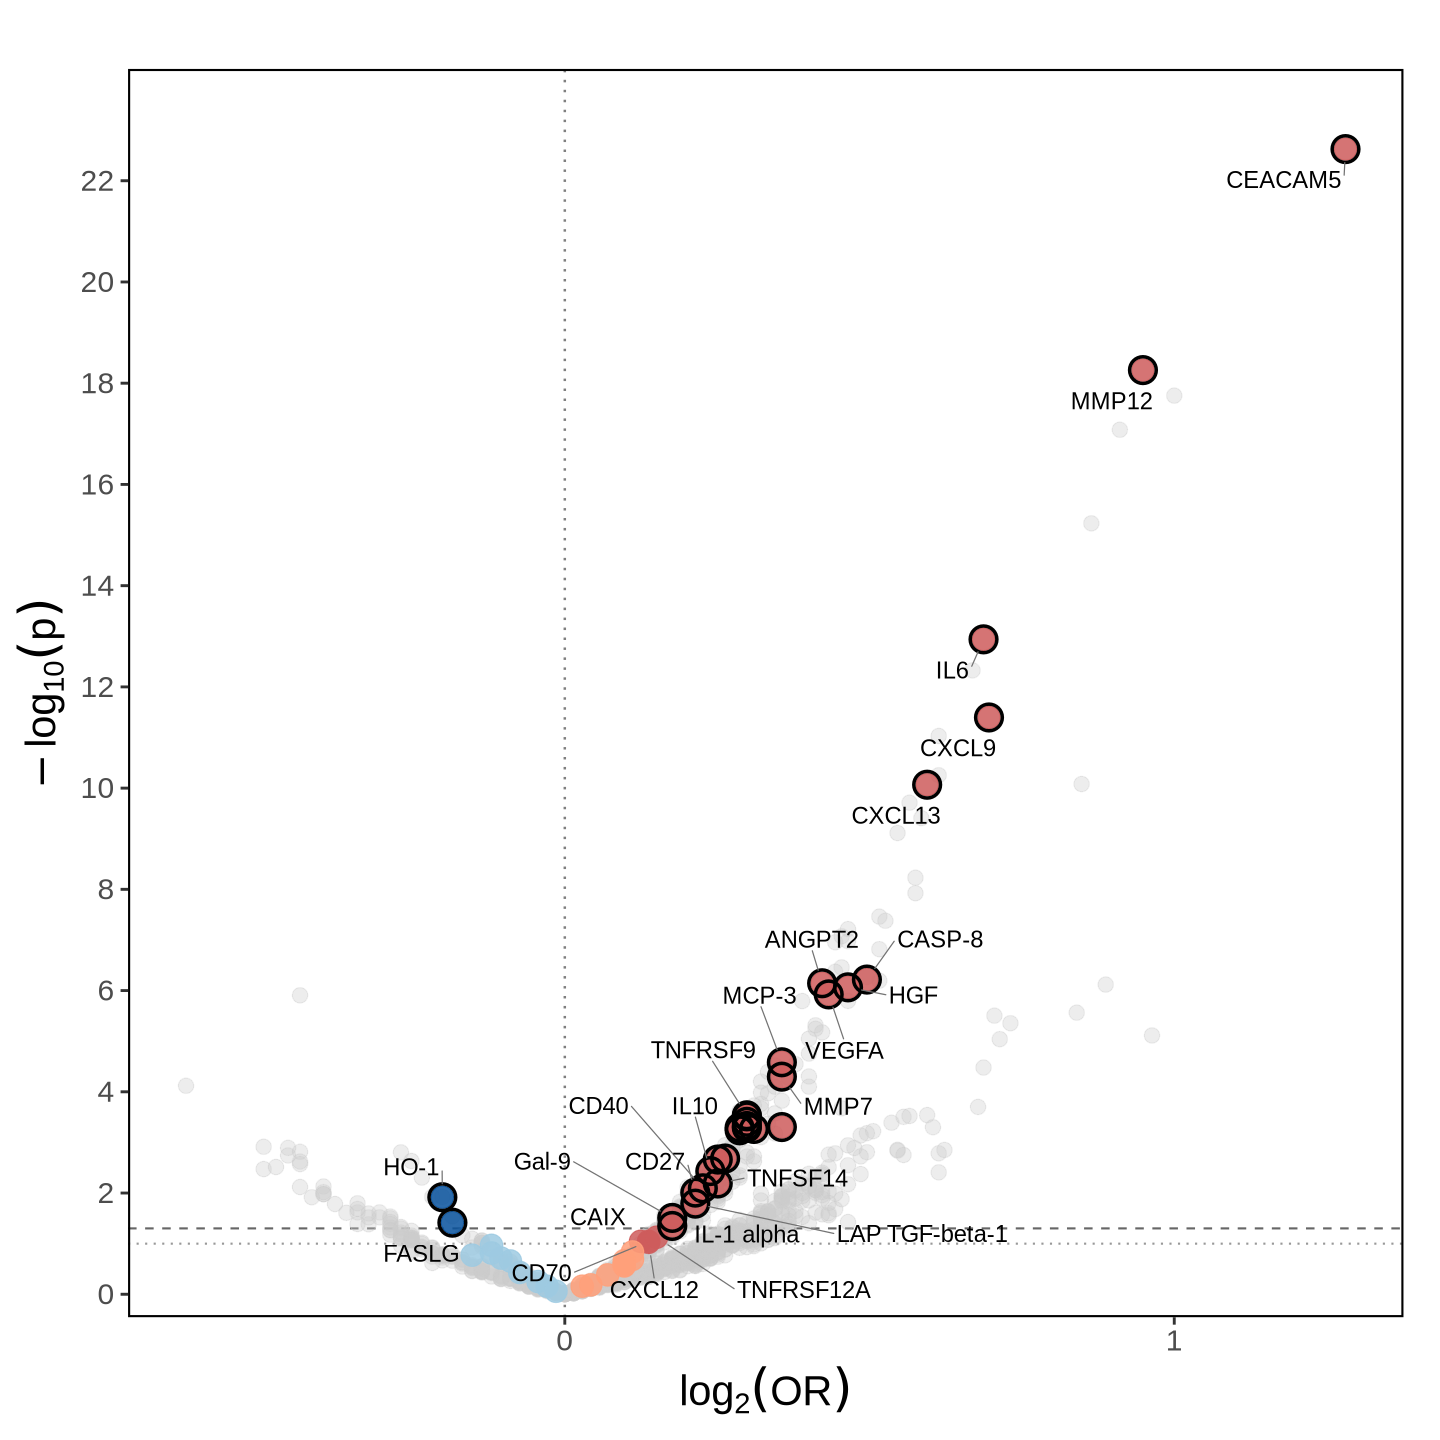

In [12]:
library(tidyverse)
library(readxl)
library(broom)
library(ggrepel)

# ================================================
# Run logistic regression for each LUCAS feature
# ================================================
logit_results <- merged_df %>%
  select(type, clinical_CEA, contains("olink_")) %>%
  filter(!is.na(type)) %>%
  mutate(type_bin = ifelse(type == "cancer", 1, 0)) %>%
  select(-type) %>%
  pivot_longer(-type_bin, names_to = "feature", values_to = "value") %>%
  group_by(feature) %>%
  nest() %>%
  mutate(
    model = map(data, ~ suppressWarnings(glm(type_bin ~ value, data = ., family = binomial()))),
    tidy  = map(model, ~ tidy(.) %>% filter(term == "value"))
  ) %>%
  unnest(tidy) %>%
  select(-data, -model) %>%
  mutate(odds_ratio = exp(estimate), log_p = -log10(p.value))

# ================================================
# Load LC3 data
# ================================================
lc3_data <- read_excel("../../data/LC3_Nature_Comm_2021_Sup_Data_4.xlsx", sheet = 1) %>%
  rename_with(~ tolower(str_replace_all(.x, "[^A-Za-z0-9]+", "_")))

# Helper to normalize protein names for matching
normalize_name <- function(x) {
  x %>%
    toupper() %>%
    str_replace_all("[_\\-\\s\\.]", "")
}

# All LC3 proteins with normalized key
lc3_for_join <- lc3_data %>%
  select(protein, or, pvalue) %>%
  mutate(protein_match = normalize_name(protein))

# ================================================
# Build result_table_full: ALL LC3 proteins,
# LUCAS joined on where available
# ================================================
result_table_full <- lc3_for_join %>%
  rename(Protein = protein, LC3_OR = or, LC3_p = pvalue) %>%
  left_join(
    logit_results %>%
      mutate(
        Protein = case_when(
          feature == "clinical_CEA" ~ "CEACAM5",
          str_starts(feature, "olink_") ~ str_remove(feature, "olink_"),
          TRUE ~ feature
        ),
        protein_match = normalize_name(Protein)
      ) %>%
      select(protein_match, LUCAS_OR = odds_ratio, LUCAS_p = p.value),
    by = "protein_match"
  ) %>%
  select(Protein, LC3_OR, LC3_p, LUCAS_OR, LUCAS_p)

cat("Total LC3 proteins:", nrow(result_table_full), "\n")
cat("Matched with LUCAS:", sum(!is.na(result_table_full$LUCAS_OR)), "\n")

# ================================================
# Prepare volcano data
# ================================================
lc3_volcano_data <- result_table_full %>%
  mutate(
    display_label = Protein,
    yval = -log10(pmax(LC3_p, .Machine$double.xmin)),

    fdr_level_primary   = 0.05,
    fdr_level_secondary = 0.10,

    sig_primary   = !is.na(LC3_p) & LC3_p < fdr_level_primary,
    sig_secondary = !is.na(LC3_p) & LC3_p >= fdr_level_primary & LC3_p < fdr_level_secondary,

    # Direction based on LC3 OR
    lc3_direction = case_when(
      is.na(LC3_OR) ~ NA_character_,
      LC3_OR > 1    ~ "Up",
      TRUE          ~ "Down"
    ),

    # Direction based on LUCAS OR
    lucas_direction = case_when(
      is.na(LUCAS_OR) ~ NA_character_,
      LUCAS_OR > 1    ~ "Up",
      TRUE            ~ "Down"
    ),

    # In LUCAS?
    in_lucas = !is.na(LUCAS_OR),

    # Direction match between LC3 and LUCAS?
    direction_match = in_lucas & !is.na(lucas_direction) & lc3_direction == lucas_direction,

    # Final color group
    grp_plot = case_when(
      in_lucas & direction_match & sig_primary   ~ paste0(lc3_direction, " primary"),
      in_lucas & direction_match & sig_secondary ~ paste0(lc3_direction, " secondary"),
      in_lucas & direction_match                 ~ paste0(lc3_direction, " ns"),
      TRUE                                       ~ "grey"
    ),

    # Label significant direction-matched LUCAS proteins
    show_label = in_lucas & direction_match & (sig_primary | sig_secondary)
  )

# ================================================
# Color palette
# ================================================
volcano_pal <- c(
  "Up primary"     = "#CD5C5C",
  "Down primary"   = "#08519C",
  "Up secondary"   = "#CD5C5C",
  "Down secondary" = "#08519C",
  "Up ns"          = "#FFA07A",
  "Down ns"        = "#9ECAE1",
  "grey"           = "grey80"
)

# ================================================
# Axis breaks
# ================================================
x_vals   <- log2(lc3_volcano_data$LC3_OR)
x_min    <- floor(min(x_vals[is.finite(x_vals)], na.rm = TRUE))
x_max    <- ceiling(max(x_vals[is.finite(x_vals)], na.rm = TRUE))
x_breaks <- seq(x_min, x_max, by = 1)

y_max    <- ceiling(max(lc3_volcano_data$yval, na.rm = TRUE))
y_breaks <- seq(0, max(2, y_max), by = 2)

# ================================================
# Volcano plot
# ================================================
lc3_volcano_plot <- ggplot() +

  # Threshold lines
  geom_hline(yintercept = -log10(0.05), linetype = "dashed", color = "gray40", linewidth = 0.6) +
  geom_hline(yintercept = -log10(0.10), linetype = "dotted", color = "gray60", linewidth = 0.6) +
  geom_vline(xintercept = 0,            linetype = "dotted", color = "gray50", linewidth = 0.7) +

  # Grey points first (underneath)
  geom_point(
    data = dplyr::filter(lc3_volcano_data, grp_plot == "grey"),
    aes(x = log2(LC3_OR), y = yval),
    color = "grey80", size = 4.0, alpha = 0.35, na.rm = TRUE
  ) +

  # Colored LUCAS-matching points on top
  geom_point(
    data = dplyr::filter(lc3_volcano_data, grp_plot != "grey"),
    aes(x = log2(LC3_OR), y = yval, color = grp_plot),
    size = 6.0, alpha = 0.85, na.rm = TRUE
  ) +

  # Black ring around primary significant points
  geom_point(
    data = dplyr::filter(lc3_volcano_data, grp_plot != "grey" & sig_primary),
    aes(x = log2(LC3_OR), y = yval),
    shape = 21, fill = NA, color = "black", stroke = 1.5, size = 6.5,
    inherit.aes = FALSE
  ) +

  # Labels for significant direction-matched LUCAS proteins
  geom_text_repel(
    data = dplyr::filter(lc3_volcano_data, show_label),
    aes(x = log2(LC3_OR), y = yval, label = display_label),
    size          = 5,
    box.padding   = 0.8,
    point.padding = 1.0,
    max.overlaps  = 20,
    segment.color = "gray45",
    segment.size  = 0.35
  ) +

  scale_color_manual(
    values = volcano_pal,
    breaks = c("Up primary", "Up secondary", "Up ns",
               "Down primary", "Down secondary", "Down ns")
  ) +

  scale_x_continuous(
    breaks = x_breaks,
    expand = expansion(mult = c(0.05, 0.05))
  ) +
  scale_y_continuous(
    breaks = y_breaks,
    limits = c(0, NA),
    expand = expansion(mult = c(0.02, 0.07))
  ) +

  labs(
    title = "",
    x     = expression(log[2](OR)),
    y     = expression(-log[10](p))
  ) +

  theme_bw(base_size = 18) +
  theme(
    panel.grid.major  = element_blank(),
    panel.grid.minor  = element_blank(),
    panel.border      = element_rect(color = "black", fill = NA, linewidth = 1.2),
    legend.position   = "none",
    axis.text         = element_text(size = 18),
    axis.title        = element_text(size = 25, face = "bold"),
    plot.background   = element_rect(fill = "white", color = NA),
    plot.margin       = margin(12, 22, 10, 10)
  )

lc3_volcano_plot

In [13]:
ggsave(
  filename = "../../outputs/Extended/Ext-Data-Fig1c-LC3-Protein-Volcano-Plot-LogOR-padj.png",   # or .pdf, .tiff, etc.
  plot     = lc3_volcano_plot,
  width    = 12,      # inches
  height   = 12,      # inches
  dpi      = 600,     # publication quality
  bg       = "white",
    create.dir = TRUE
)


Warning message:
“ggrepel: 11 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


In [ ]:
## Done ##